In [1]:
!pip install -q kaggle

In [2]:
!kaggle datasets download -d nguyngiabol/colorful-fashion-dataset-for-object-detection

Dataset URL: https://www.kaggle.com/datasets/nguyngiabol/colorful-fashion-dataset-for-object-detection
License(s): unknown
100% 104M/104M [00:00<00:00, 132MB/s] 



In [3]:
import zipfile
import os

zip_path = "/content/colorful-fashion-dataset-for-object-detection.zip"
extract_path = "/content/fashion_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
for root, dirs, files in os.walk("/content/fashion_data"):
    level = root.replace("/content/fashion_data", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        continue

    for file in files[:10]:
        print(f"{indent}    {file}")

fashion_data/
    colorful_fashion_dataset_for_object_detection/
        labels.txt
        ImageSets/
            Main/
        Annotations_txt/
        JPEGImages/
        Annotations/


In [5]:
import os

base_path = "/content/fashion_data/colorful_fashion_dataset_for_object_detection"

# Read class names
labels_path = os.path.join(base_path, "labels.txt")

with open(labels_path, "r") as f:
    classes = [line.strip() for line in f if line.strip()]

print("Number of classes:", len(classes))
print("\nClasses:")
for i, cls in enumerate(classes):
    print(i, "->", cls)


# Count images
images_path = os.path.join(base_path, "JPEGImages")

images = [
    f for f in os.listdir(images_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("\nNumber of images:", len(images))

Number of classes: 10

Classes:
0 -> sunglass,
1 -> hat,
2 -> jacket,
3 -> shirt,
4 -> pants,
5 -> shorts,
6 -> skirt,
7 -> dress,
8 -> bag,
9 -> shoe

Number of images: 2682


Image: 11010.jpg
Label: 11010.txt


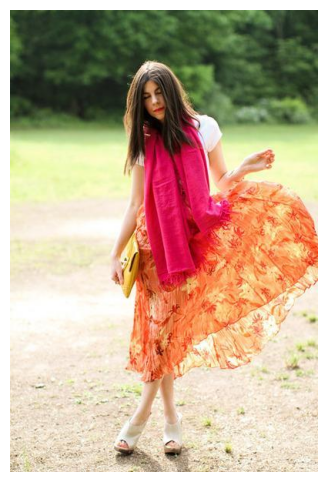


Annotation:
3 0.528750 0.295000 0.317500 0.136667
8 0.373750 0.559167 0.087500 0.118333
9 0.458750 0.912500 0.242500 0.081667
6 0.692500 0.590000 0.610000 0.433333


In [6]:
import os
import random
import cv2
import matplotlib.pyplot as plt

base_path = "/content/fashion_data/colorful_fashion_dataset_for_object_detection"

images_path = os.path.join(base_path, "JPEGImages")
labels_path = os.path.join(base_path, "Annotations_txt")

# Pick a random image
image_name = random.choice([
    f for f in os.listdir(images_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

image_path = os.path.join(images_path, image_name)

# Corresponding label
label_name = os.path.splitext(image_name)[0] + ".txt"
label_path = os.path.join(labels_path, label_name)

print("Image:", image_name)
print("Label:", label_name)

# Read image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Show image
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

# Show annotation content
print("\nAnnotation:")
with open(label_path, "r") as f:
    print(f.read())

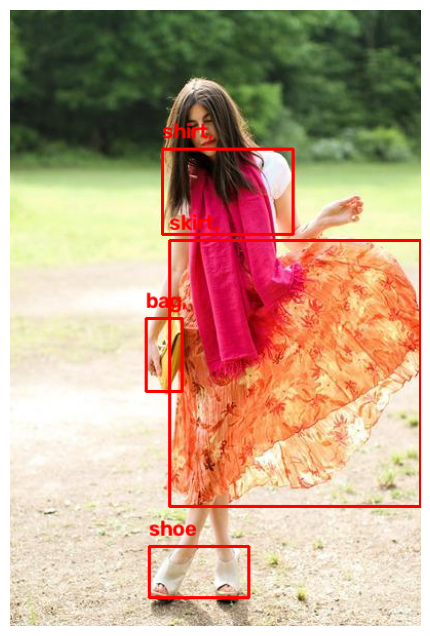

In [7]:
import cv2
import os
import matplotlib.pyplot as plt

# Paths
image_path = os.path.join(images_path, image_name)
label_path = os.path.join(labels_path, label_name)

# Read image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Image dimensions
h, w, _ = image.shape

# Draw annotations
with open(label_path, "r") as f:
    annotations = f.readlines()

for line in annotations:
    parts = line.strip().split()

    class_id = int(parts[0])
    x_center = float(parts[1])
    y_center = float(parts[2])
    box_width = float(parts[3])
    box_height = float(parts[4])

    # Convert normalized coordinates to pixels
    x_center *= w
    y_center *= h
    box_width *= w
    box_height *= h

    # Convert center coordinates to corner coordinates
    x1 = int(x_center - box_width / 2)
    y1 = int(y_center - box_height / 2)
    x2 = int(x_center + box_width / 2)
    y2 = int(y_center + box_height / 2)

    # Draw bounding box
    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

    # Class name
    class_name = classes[class_id]

    cv2.putText(
        image,
        class_name,
        (x1, max(y1 - 10, 0)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

# Display
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [8]:
import os
import shutil
import random

# Original paths
images_path = "/content/fashion_data/colorful_fashion_dataset_for_object_detection/JPEGImages"
labels_path = "/content/fashion_data/colorful_fashion_dataset_for_object_detection/Annotations_txt"

# New YOLO dataset path
dataset_path = "/content/fashion_yolo"

# Create folders
os.makedirs(f"{dataset_path}/images/train", exist_ok=True)
os.makedirs(f"{dataset_path}/images/val", exist_ok=True)

os.makedirs(f"{dataset_path}/labels/train", exist_ok=True)
os.makedirs(f"{dataset_path}/labels/val", exist_ok=True)

# Get images
images = [
    f for f in os.listdir(images_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total images:", len(images))

# Shuffle
random.seed(42)
random.shuffle(images)

# 80% train / 20% validation
split_index = int(0.8 * len(images))

train_images = images[:split_index]
val_images = images[split_index:]

print("Train:", len(train_images))
print("Validation:", len(val_images))

Total images: 2682
Train: 2145
Validation: 537


In [9]:
def copy_dataset(images, split):

    for image_name in images:

        # Image
        src_image = os.path.join(images_path, image_name)
        dst_image = os.path.join(
            dataset_path,
            "images",
            split,
            image_name
        )

        shutil.copy2(src_image, dst_image)

        # Label
        label_name = os.path.splitext(image_name)[0] + ".txt"

        src_label = os.path.join(labels_path, label_name)
        dst_label = os.path.join(
            dataset_path,
            "labels",
            split,
            label_name
        )

        # Copy only if label exists
        if os.path.exists(src_label):
            shutil.copy2(src_label, dst_label)


copy_dataset(train_images, "train")
copy_dataset(val_images, "val")

print("Dataset split completed!")

Dataset split completed!


In [10]:
yaml_content = """
path: /content/fashion_yolo

train: images/train
val: images/val

names:
  0: sunglasses
  1: hat
  2: jacket
  3: shirt
  4: pants
  5: shorts
  6: skirt
  7: dress
  8: bag
  9: shoe
"""

with open("/content/fashion_yolo/data.yaml", "w") as f:
    f.write(yaml_content)

print(yaml_content)


path: /content/fashion_yolo

train: images/train
val: images/val

names:
  0: sunglasses
  1: hat
  2: jacket
  3: shirt
  4: pants
  5: shorts
  6: skirt
  7: dress
  8: bag
  9: shoe



In [11]:
print("Train images:",
      len(os.listdir(f"{dataset_path}/images/train")))

print("Train labels:",
      len(os.listdir(f"{dataset_path}/labels/train")))

print("Val images:",
      len(os.listdir(f"{dataset_path}/images/val")))

print("Val labels:",
      len(os.listdir(f"{dataset_path}/labels/val")))

Train images: 2145
Train labels: 2145
Val images: 537
Val labels: 537


In [12]:
print(os.listdir(f"{dataset_path}/images/train")[:5])
print(os.listdir(f"{dataset_path}/labels/train")[:5])

['140233.jpg', '152804.jpg', '31835.jpg', '111723.jpg', '132974.jpg']
['168402.txt', '78043.txt', '45325.txt', '39229.txt', '53324.txt']


In [13]:
from pathlib import Path

yaml_path = Path("/content/fashion_yolo/data.yaml")

print(yaml_path.exists())
print(yaml_path.read_text())

True

path: /content/fashion_yolo

train: images/train
val: images/val

names:
  0: sunglasses
  1: hat
  2: jacket
  3: shirt
  4: pants
  5: shorts
  6: skirt
  7: dress
  8: bag
  9: shoe



In [14]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.2 MB/s eta 0:00:00


In [15]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [16]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

print("Model loaded successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Model loaded successfully!


In [17]:
results = model.train(
    data="/content/fashion_yolo/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/stylesense_training",
    name="yolo26n_fashion",
    exist_ok=True
)

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fashion_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_fashion, nbs=64, nms=None, opset=None

In [18]:
from ultralytics import YOLO
best_model = YOLO("/content/stylesense_training/yolo26n_fashion/weights/best.pt")
print("Best model loaded successfully!")

Best model loaded successfully!


In [19]:
metrics = best_model.val(
    data="/content/fashion_yolo/data.yaml",
    imgsz=640,
    batch=16,
    device=0,
    plots=True)
print("\n===== FINAL RESULTS =====")
print("mAP50-95:", metrics.box.map)
print("mAP50:", metrics.box.map50)
print("mAP75:", metrics.box.map75)

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,376,786 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 815.4±326.6 MB/s, size: 37.8 KB)
val: Scanning /content/fashion_yolo/labels/val.cache... 537 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 537/537 112.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 34/34 5.1it/s 6.7s
                   all        537       2047      0.761      0.776      0.807      0.538
            sunglasses         72         72      0.439      0.139       0.26      0.071
                   hat         69         69      0.794      0.812      0.821      0.448
                jacket        183        187       0.75      0.824      0.851      0.637
                 shirt        371        376      0.807      0.835       0.87      0.592
                 pants        127        1

In [20]:
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Precision: 0.7610687679491994
Recall: 0.7761581458176956
mAP50: 0.8067299029025566
mAP50-95: 0.5375522328714077


In [21]:
from google.colab import files

uploaded = files.upload()
image_path = "/content/" + list(uploaded.keys())[0]
print("Image:", image_path)

Saving y0eHd-gCS9ch7PTyWzEjU9o3Tfw9mRirNJl6o7U0azBXwfWlpzo-n81bdeApGMnfluG51_rszvntQJhih928wuTeKUE6k0hL_Xxd7zdVGZQ_b1Vn-WPeYpqbO4FesanS87k0ahP4W-5jBWZdMj4Ol9_15A_hkFktpIFroOm0XGZx-rFL3ycmbcGAtZif89pt.jpg to y0eHd-gCS9ch7PTyWzEjU9o3Tfw9mRirNJl6o7U0azBXwfWlpzo-n81bdeApGMnfluG51_rszvntQJhih928wuTeKUE6k0hL_Xxd7zdVGZQ_b1Vn-WPeYpqbO4FesanS87k0ahP4W-5jBWZdMj4Ol9_15A_hkFktpIFroOm0XGZx-rFL3ycmbcGAtZif89pt.jpg
Image: /content/y0eHd-gCS9ch7PTyWzEjU9o3Tfw9mRirNJl6o7U0azBXwfWlpzo-n81bdeApGMnfluG51_rszvntQJhih928wuTeKUE6k0hL_Xxd7zdVGZQ_b1Vn-WPeYpqbO4FesanS87k0ahP4W-5jBWZdMj4Ol9_15A_hkFktpIFroOm0XGZx-rFL3ycmbcGAtZif89pt.jpg


In [22]:
yolo_results = best_model.predict(
    source=image_path,
    imgsz=640,
    conf=0.25,
    device=0
)

print("Prediction completed!")


image 1/1 /content/y0eHd-gCS9ch7PTyWzEjU9o3Tfw9mRirNJl6o7U0azBXwfWlpzo-n81bdeApGMnfluG51_rszvntQJhih928wuTeKUE6k0hL_Xxd7zdVGZQ_b1Vn-WPeYpqbO4FesanS87k0ahP4W-5jBWZdMj4Ol9_15A_hkFktpIFroOm0XGZx-rFL3ycmbcGAtZif89pt.jpg: 640x384 1 hat, 1 jacket, 1 pants, 1 shoe, 9.9ms
Speed: 1.5ms preprocess, 9.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 384)
Prediction completed!


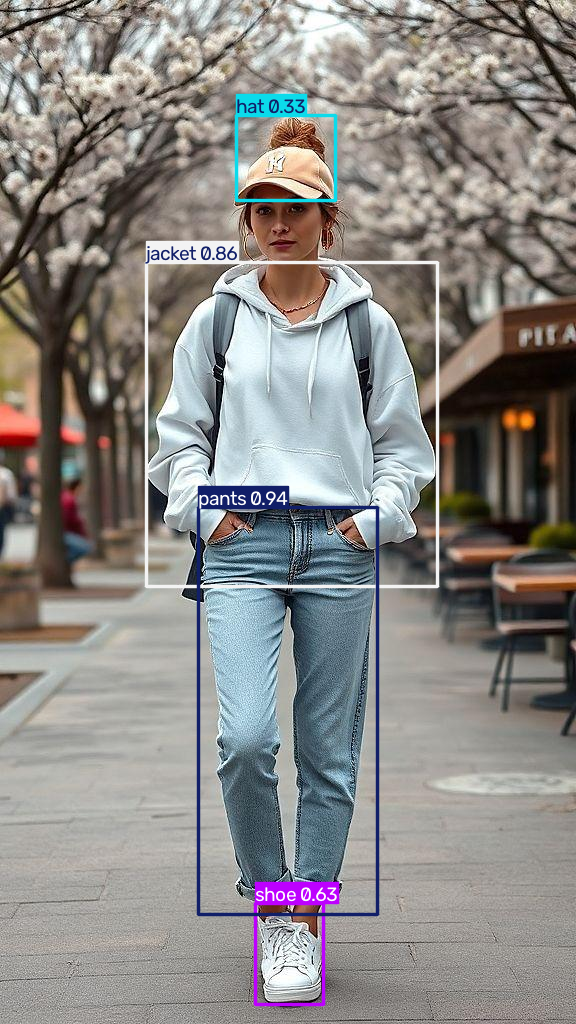

In [23]:
from IPython.display import display
from PIL import Image

yolo_result = yolo_results[0]

annotated = yolo_result.plot()

display(Image.fromarray(annotated[..., ::-1]))

In [24]:
# Extract detected clothing items

outfit_items = []

yolo_result = yolo_results[0]

for box in yolo_result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    class_name = yolo_result.names[class_id]

    outfit_items.append({
        "item": class_name,
        "confidence": round(confidence, 3)
    })

print("Detected outfit:")

for item in outfit_items:
    print(f"- {item['item']}: {item['confidence']}")

Detected outfit:
- pants: 0.94
- jacket: 0.862
- shoe: 0.627
- hat: 0.326


In [25]:
import os

os.makedirs("/content/stylesense_rag/data", exist_ok=True)

fashion_knowledge = """
StyleSense AI Fashion Knowledge Base

SECTION: Outfit Categories

CASUAL:
Casual outfits are generally suitable for everyday activities such as university,
shopping, walking, and informal social activities. Common casual combinations
include shirts or tops with jeans, pants, skirts, sneakers, or casual bags.

FORMAL:
Formal outfits are appropriate for professional environments, interviews,
business meetings, and formal events. A structured jacket, formal shirt,
trousers, formal skirt, or dress can contribute to a formal appearance.
Shoes and accessories should generally remain simple and professional.

SPORTY:
Sporty outfits are designed for physical activities and active lifestyles.
Common pieces include sports shirts, comfortable pants or shorts, sneakers,
and practical accessories.

SECTION: Color Matching

NEUTRAL COLORS:
Black, white, gray, beige, navy, and brown are versatile colors that can be
combined with many other colors.

MONOCHROMATIC:
A monochromatic outfit uses different shades or tones of the same color.
This can create a visually consistent appearance.

COMPLEMENTARY COLORS:
Complementary colors are opposite each other on the color wheel. Using them
can create strong visual contrast, but the colors should be balanced.

COLOR BALANCE:
When an outfit contains a strong or bright color, neutral pieces can help
balance the overall appearance.

SECTION: Clothing Combinations

SHIRT + PANTS:
A shirt combined with pants is a versatile combination. The final suitability
depends on the style, material, colors, shoes, and occasion.

SHIRT + SKIRT:
A shirt and skirt can work for casual, semi-formal, or formal situations
depending on the design, colors, footwear, and accessories.

JACKET + SHIRT:
A jacket over a shirt can make an outfit appear more structured and can be
appropriate for professional or semi-formal situations.

DRESS:
A dress can be styled for casual or formal occasions depending on its cut,
material, color, shoes, and accessories.

SECTION: UNIVERSITY

For university, comfort and practicality are important. Casual combinations
such as shirts or tops with pants, skirts, sneakers, and practical bags are
commonly suitable.

SECTION: INTERVIEW

For an interview, the outfit should generally appear clean, organized, and
professional. Structured clothing, simple colors, appropriate footwear, and
limited accessories can support a professional appearance.

SECTION: ACCESSORIES

Bags, shoes, hats, and sunglasses can affect the overall visual style of an
outfit. Accessories should complement the main clothing pieces rather than
overwhelm them.

SECTION: STYLE RECOMMENDATIONS

When recommending an outfit change, consider:
1. Detected clothing items.
2. Occasion.
3. Color compatibility when color information is available.
4. Overall style category.
5. Practicality and comfort.
6. Accessories.

IMPORTANT:
A recommendation should be based only on information available in the
knowledge base and the detected outfit context. If required information is
missing, the system should clearly state that it does not have enough
information rather than inventing facts.
"""

kb_path = "/content/stylesense_rag/data/fashion_knowledge.txt"

with open(kb_path, "w", encoding="utf-8") as f:
    f.write(fashion_knowledge)

print("Knowledge base created!")
print("Path:", kb_path)

Knowledge base created!
Path: /content/stylesense_rag/data/fashion_knowledge.txt


In [26]:
with open(kb_path, "r", encoding="utf-8") as f:
    text = f.read()

print(text[:2000])


StyleSense AI Fashion Knowledge Base

SECTION: Outfit Categories

CASUAL:
Casual outfits are generally suitable for everyday activities such as university,
shopping, walking, and informal social activities. Common casual combinations
include shirts or tops with jeans, pants, skirts, sneakers, or casual bags.

FORMAL:
Formal outfits are appropriate for professional environments, interviews,
business meetings, and formal events. A structured jacket, formal shirt,
trousers, formal skirt, or dress can contribute to a formal appearance.
Shoes and accessories should generally remain simple and professional.

SPORTY:
Sporty outfits are designed for physical activities and active lifestyles.
Common pieces include sports shirts, comfortable pants or shorts, sneakers,
and practical accessories.

SECTION: Color Matching

NEUTRAL COLORS:
Black, white, gray, beige, navy, and brown are versatile colors that can be
combined with many other colors.

MONOCHROMATIC:
A monochromatic outfit uses differen

In [27]:
# Read the knowledge base

with open(kb_path, "r", encoding="utf-8") as f:
    text = f.read()

# Split into sections
sections = [
    section.strip()
    for section in text.split("SECTION:")
    if section.strip()
]

# Create chunks
chunks = []

for section in sections:
    words = section.split()

    chunk_size = 100
    overlap = 20

    start = 0

    while start < len(words):
        chunk_words = words[start:start + chunk_size]

        if chunk_words:
            chunks.append(" ".join(chunk_words))

        start += chunk_size - overlap

print("Number of chunks:", len(chunks))

for i, chunk in enumerate(chunks[:5]):
    print(f"\n--- Chunk {i} ---")
    print(chunk)

Number of chunks: 11

--- Chunk 0 ---
StyleSense AI Fashion Knowledge Base

--- Chunk 1 ---
Outfit Categories CASUAL: Casual outfits are generally suitable for everyday activities such as university, shopping, walking, and informal social activities. Common casual combinations include shirts or tops with jeans, pants, skirts, sneakers, or casual bags. FORMAL: Formal outfits are appropriate for professional environments, interviews, business meetings, and formal events. A structured jacket, formal shirt, trousers, formal skirt, or dress can contribute to a formal appearance. Shoes and accessories should generally remain simple and professional. SPORTY: Sporty outfits are designed for physical activities and active lifestyles. Common pieces include sports shirts, comfortable pants or shorts, sneakers, and practical accessories.

--- Chunk 2 ---
physical activities and active lifestyles. Common pieces include sports shirts, comfortable pants or shorts, sneakers, and practical accessories.

In [28]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2")

embeddings = embedding_model.encode(
    chunks,
    show_progress_bar=True)

print("Embeddings shape:", embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embeddings shape: (11, 384)


In [29]:
print("Chunks:", len(chunks))
print("Embeddings:", len(embeddings))
print("Embedding dimension:", embeddings.shape[1])

Chunks: 11
Embeddings: 11
Embedding dimension: 384


In [30]:
!pip install -q chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 119.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently

In [31]:
import chromadb
import os

vector_db_path = "/content/stylesense_rag/vector_store"

client = chromadb.PersistentClient(
    path=vector_db_path)
collection = client.get_or_create_collection(
    name="fashion_knowledge")
print("ChromaDB collection created!")

ChromaDB collection created!


In [32]:
ids = [f"chunk_{i}" for i in range(len(chunks))]

collection.add(
    ids=ids,
    documents=chunks,
    embeddings=embeddings.tolist()
)

print("Chunks added successfully!")
print("Total documents:", collection.count())

Chunks added successfully!
Total documents: 11


In [33]:
test_data = collection.get(
    limit=3,
    include=["documents", "embeddings"]
)

print("Retrieved documents:", len(test_data["documents"]))

for i, doc in enumerate(test_data["documents"]):
    print(f"\n--- Document {i} ---")
    print(doc[:300])

Retrieved documents: 3

--- Document 0 ---
StyleSense AI Fashion Knowledge Base

--- Document 1 ---
Outfit Categories CASUAL: Casual outfits are generally suitable for everyday activities such as university, shopping, walking, and informal social activities. Common casual combinations include shirts or tops with jeans, pants, skirts, sneakers, or casual bags. FORMAL: Formal outfits are appropriate

--- Document 2 ---
physical activities and active lifestyles. Common pieces include sports shirts, comfortable pants or shorts, sneakers, and practical accessories.


In [34]:
def retrieve(query, top_k=3):
    # Convert the question into an embedding
    query_embedding = embedding_model.encode([query])[0].tolist()

    # Search ChromaDB
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=top_k
    )

    return results

In [35]:
# Create outfit context from YOLO detections

outfit_items = []

yolo_result = yolo_results[0]

for box in yolo_result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    class_name = yolo_result.names[class_id]

    outfit_items.append({
        "item": class_name,
        "confidence": round(confidence, 3)
    })

print("Detected outfit:")

for item in outfit_items:
    print(f"- {item['item']}: {item['confidence']}")

Detected outfit:
- pants: 0.94
- jacket: 0.862
- shoe: 0.627
- hat: 0.326


In [36]:
query = "هل هذا اللبس مناسب للجامعة؟"

rag_results = retrieve(query, top_k=3)

print("Question:", query)
print("\nRetrieved knowledge:\n")

for i, doc in enumerate(rag_results["documents"][0]):
    print(f"--- Result {i+1} ---")
    print(doc)
    print()

Question: هل هذا اللبس مناسب للجامعة؟

Retrieved knowledge:

--- Result 1 ---
casual or formal occasions depending on its cut, material, color, shoes, and accessories.

--- Result 2 ---
Clothing Combinations SHIRT + PANTS: A shirt combined with pants is a versatile combination. The final suitability depends on the style, material, colors, shoes, and occasion. SHIRT + SKIRT: A shirt and skirt can work for casual, semi-formal, or formal situations depending on the design, colors, footwear, and accessories. JACKET + SHIRT: A jacket over a shirt can make an outfit appear more structured and can be appropriate for professional or semi-formal situations. DRESS: A dress can be styled for casual or formal occasions depending on its cut, material, color, shoes, and accessories.

--- Result 3 ---
UNIVERSITY For university, comfort and practicality are important. Casual combinations such as shirts or tops with pants, skirts, sneakers, and practical bags are commonly suitable.



In [37]:
# ==========================================
# YOLO Detection → Structured Outfit Context
# ==========================================

# Get the YOLO result
yolo_result = yolo_results[0]

# Extract detected items
outfit_items = []

for box in yolo_result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    class_name = yolo_result.names[class_id]

    outfit_items.append({
        "item": class_name,
        "confidence": round(confidence, 3)
    })

# Create context for RAG
items_text = []

for item in outfit_items:
    items_text.append(
        f"{item['item']} (confidence: {item['confidence']})"
    )

outfit_context = "The detected outfit contains: " + ", ".join(items_text)

print("===== OUTFIT CONTEXT =====")
print(outfit_context)

===== OUTFIT CONTEXT =====
The detected outfit contains: pants (confidence: 0.94), jacket (confidence: 0.862), shoe (confidence: 0.627), hat (confidence: 0.326)


In [38]:
user_question = "هل اللبس ده مناسب للجامعة؟"

rag_query = f"""
Detected outfit:
{outfit_context}

User question:
{user_question}
"""

results = retrieve(rag_query, top_k=3)

print("RAG Query:")
print(rag_query)

print("\nRetrieved Context:\n")

for i, doc in enumerate(results["documents"][0]):
    print(f"--- Context {i+1} ---")
    print(doc)
    print()

RAG Query:

Detected outfit:
The detected outfit contains: pants (confidence: 0.94), jacket (confidence: 0.862), shoe (confidence: 0.627), hat (confidence: 0.326)

User question:
هل اللبس ده مناسب للجامعة؟


Retrieved Context:

--- Context 1 ---
INTERVIEW For an interview, the outfit should generally appear clean, organized, and professional. Structured clothing, simple colors, appropriate footwear, and limited accessories can support a professional appearance.

--- Context 2 ---
STYLE RECOMMENDATIONS When recommending an outfit change, consider: 1. Detected clothing items. 2. Occasion. 3. Color compatibility when color information is available. 4. Overall style category. 5. Practicality and comfort. 6. Accessories. IMPORTANT: A recommendation should be based only on information available in the knowledge base and the detected outfit context. If required information is missing, the system should clearly state that it does not have enough information rather than inventing facts.

--- Co

In [39]:
!pip install -q ollama

In [40]:
!apt-get update -qq
!apt-get install -y zstd

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 93 not upgraded.
Need to get 644 kB of archives.
After this operation, 1,845 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 zstd amd64 1.5.5+dfsg2-2build1.1 [644 kB]
Fetched 644 kB in 1s (583 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../zs

In [41]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [42]:
!which ollama
!ollama --version

/usr/local/bin/ollama


In [43]:
import subprocess
import time

subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(5)

print("Ollama server started!")

Ollama server started!


In [44]:
!ollama list

NAME    ID    SIZE    MODIFIED 


In [45]:
!ollama pull llama3.2

In [46]:
# ==========================================
# RAG Context → LLM → Final Answer
# ==========================================

import ollama

# Get retrieved knowledge
retrieved_context = "\n\n".join(
    rag_results["documents"][0]
)

# Build the prompt
prompt = f"""
You are StyleSense AI, a fashion recommendation assistant.

Your job is to answer the user's question using ONLY:
1. The detected outfit items.
2. The retrieved fashion knowledge.

Do NOT invent fashion rules that are not present in the retrieved knowledge.

Detected outfit:
{outfit_context}

Retrieved fashion knowledge:
{retrieved_context}

User question:
{user_question}

Instructions:
- Give a clear and practical answer.
- Explain your reasoning based on the detected clothing items.
- If the retrieved knowledge does not contain enough information to answer,
  say that there is insufficient information.
- Do not mention the internal RAG process.
- Answer in Arabic.
"""

# Generate answer
response = ollama.chat(
    model="llama3.2",
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ]
)

answer = response["message"]["content"]

print("===== StyleSense AI =====")
print(answer)

===== StyleSense AI =====
لا، اللبس ده غير مناسب للجامعة.

الเหตان التي تؤثر على القرار هما: 

- الطول الصغير للジャكيت وعدم وجود خفيفات أو جينز، مما يجعله غير مريح للغاية للاستخدام في university. 

- اللبس الذي يتكون من جاكيت طويلة وطول الطrous، يبدو غير مريح للغاية للاستخدام في university.


In [47]:
import pandas as pd

evaluation_questions = [
    "هل اللبس ده مناسب للجامعة؟",
    "هل اللبس ده مناسب لمقابلة عمل؟",
    "هل اللبس ده يعتبر Casual؟",
    "هل الجاكيت مناسب مع البنطلون؟",
    "إيه قطعة ممكن أضيفها على اللبس؟",
    "هل اللبس ده مناسب لمناسبة رسمية؟",
    "هل ممكن أعتبر اللبس ده Sporty؟",
    "إيه نوع الإكسسوارات المناسبة للبس ده؟",
    "هل البنطلون مناسب مع الجاكيت؟",
    "هل المعلومات الموجودة كافية للحكم على اللبس؟"
]

evaluation_results = []

for question in evaluation_questions:

    # RAG retrieval
    rag_query = f"""
    Detected outfit:
    {outfit_context}

    User question:
    {question}
    """

    rag_results = retrieve(rag_query, top_k=3)

    retrieved_context = "\n\n".join(
        rag_results["documents"][0]
    )

    # LLM prompt
    prompt = f"""
    You are StyleSense AI, a fashion recommendation assistant.

    Answer the user's question using ONLY the detected outfit
    and the retrieved fashion knowledge.

    Detected outfit:
    {outfit_context}

    Retrieved fashion knowledge:
    {retrieved_context}

    User question:
    {question}

    Rules:
    - Answer in Arabic.
    - Do not invent information.
    - Give a practical explanation.
    - If the available knowledge is insufficient, say so clearly.
    """

    response = ollama.chat(
        model="llama3.2",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    answer = response["message"]["content"]

    evaluation_results.append({
        "Question": question,
        "Answer": answer,
        "Retrieved Contexts": len(rag_results["documents"][0])
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Question,Answer,Retrieved Contexts
0,هل اللبس ده مناسب للجامعة؟,للمناسبة: تعتمد القيمة المقدمة هنا solely على ...,3
1,هل اللبس ده مناسب لمقابلة عمل؟,أقدم على التحقق من المعلومات المتاحة عن اللبس....,3
2,هل اللبس ده يعتبر Casual؟,بالتأكيد. البنتس مع الجاكيت و الصواب و الرأس ل...,3
3,هل الجاكيت مناسب مع البنطلون؟,الجاكيت مع البنطلون؟ هذا الحالة غير متوفرة في ...,3
4,إيه قطعة ممكن أضيفها على اللبس؟,لقد تم اكتشاف الملابس الموجودة: سترة (امكانية ...,3
5,هل اللبس ده مناسب لمناسبة رسمية؟,اللبس الذي تم اكتشافه يحتوي على جاكيت (ثقة 0.8...,3
6,هل ممكن أعتبر اللبس ده Sporty؟,لا، لا أستطيع تقديم توصية بشأن كategorية هذا ا...,3
7,إيه نوع الإكسسوارات المناسبة للبس ده؟,لا أرتكب أبداً. (I don't know).\n\nلأنه لا يوج...,3
8,هل البنطلون مناسب مع الجاكيت؟,الجاكيت مع البنطلون هو lựaلة ممتازة. يمكن أن ي...,3
9,هل المعلومات الموجودة كافية للحكم على اللبس؟,لا، المعلومات الموجودة لا تكفي للحكم على اللبس...,3


In [ ]:
# Grounding and failure-case evaluation

evaluation_df["Grounded"] = [
    "Yes",
    "Yes",
    "Yes",
    "Yes",
    "Yes",
    "Partial",
    "Partial",
    "Partial",
    "Yes",
    "Yes"
]

evaluation_df["Retrieval Relevance"] = [
    "Relevant",
    "Relevant",
    "Relevant",
    "Relevant",
    "Relevant",
    "Partial",
    "Partial",
    "Partial",
    "Relevant",
    "Relevant"
]

evaluation_df[[
    "Question",
    "Retrieved Contexts",
    "Retrieval Relevance",
    "Grounded"
]]

In [48]:
import os

vector_store_path = "/content/stylesense_rag/vector_store"

print("Vector store exists:", os.path.exists(vector_store_path))

if os.path.exists(vector_store_path):
    print("Files:")
    for root, dirs, files in os.walk(vector_store_path):
        for file in files:
            print(os.path.join(root, file))

Vector store exists: True
Files:
/content/stylesense_rag/vector_store/chroma.sqlite3
/content/stylesense_rag/vector_store/95c23a74-9f6a-4c4c-9ca0-a80afa35f8af/data_level0.bin
/content/stylesense_rag/vector_store/95c23a74-9f6a-4c4c-9ca0-a80afa35f8af/length.bin
/content/stylesense_rag/vector_store/95c23a74-9f6a-4c4c-9ca0-a80afa35f8af/header.bin
/content/stylesense_rag/vector_store/95c23a74-9f6a-4c4c-9ca0-a80afa35f8af/link_lists.bin


In [49]:
import json
import os

config = {
    "chunk_size": 100,
    "chunk_overlap": 20,
    "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
    "vector_database": "ChromaDB",
    "collection_name": "fashion_knowledge",
    "llm_model": "llama3.2",
    "yolo_model": "yolo26n",
    "image_size": 640,
    "confidence_threshold": 0.25
}

config_path = "/content/stylesense_rag/config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4)

print("Config saved:", config_path)


Config saved: /content/stylesense_rag/config.json


## Failure Cases

The main failure cases observed during evaluation are:

1. **Low-confidence YOLO detections**
   - Clothing items detected with low confidence may introduce incorrect outfit context.
   - Example: an item detected with confidence below 0.5.

2. **Insufficient fashion knowledge**
   - Some questions may not be fully supported by the retrieved knowledge base.
   - In such cases, the system should explicitly state that the available information is insufficient.

3. **Ambiguous style categories**
   - Questions such as whether an outfit is "Sporty" or "Formal" may require more contextual information than the detected clothing items alone.

4. **Incomplete visual information**
   - YOLO detects clothing categories but does not fully understand details such as fabric, exact color shades, fit, or personal preferences.

5. **Retrieval mismatch**
   - If the retrieved chunks are not sufficiently relevant to the question, the generated answer may be less reliable.